# EDA — Horno Fusor RONAL GROUP
## MA2008B · Avance 2 · Equipo 1 (Control Moderno)

Análisis exploratorio del dataset `dataset_horno_fusor1.csv`, alineado con las siete preguntas guía del segundo avance para horno fusor:

1. Setup
2. Detección de datos faltantes
3. Detección de valores atípicos
4. Distribución de variables
5. Correlaciones entre variables
6. Autocorrelación de la temperatura
7. Análisis espectral
8. Relación multivariable


## 1. Setup

Cargamos las librerías y el dataset. También reconstruimos la marca de tiempo (`timestamp`) para que cada muestra quede separada 20 segundos y ordenada en el tiempo.

In [3]:
# Cargar datos y reconstruir el timestamp (una muestra cada 20 s)
import numpy as np
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110})

df = pd.read_csv('dataset_horno_fusor1.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)
df['intra'] = df.groupby('timestamp').cumcount()
df['timestamp'] = df['timestamp'] + pd.to_timedelta(df['intra']*20, unit='s')
df = df.drop(columns='intra').set_index('timestamp').sort_index()

print(f'Shape: {df.shape}')
print(f'Rango temporal: {df.index.min()}  →  {df.index.max()}')
print(f'Frecuencia: una muestra cada 20 s (3 por minuto)')
df.head()

Shape: (21600, 8)
Rango temporal: 2026-01-01 00:00:00  →  2026-01-05 23:59:40
Frecuencia: una muestra cada 20 s (3 por minuto)


,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption
timestamp,,,,,,,,
2026-01-01 00:00:00,735.014,780.00,99.039,95.934,603.535,20.167,5.137,444.246
2026-01-01 00:00:20,746.625,780.00,99.039,95.934,591.731,20.606,5.250,453.061
2026-01-01 00:00:40,754.206,780.00,90.636,94.896,736.611,19.651,5.127,410.439
2026-01-01 00:01:00,759.186,780.01,83.374,89.775,738.020,19.685,5.163,378.931
2026-01-01 00:01:20,769.235,780.01,76.893,89.089,699.088,19.657,5.199,351.671


## 2. Detección de datos faltantes

Revisamos cuántos valores vacíos (NaN) hay en cada columna y qué tan grande es el problema.

In [ ]:
# Contar NaN por columna y % de filas afectadas
faltantes = df.isna().sum()
print('Valores faltantes por columna:')
print(faltantes[faltantes > 0])
print(f'\nTotal de filas: {len(df)}')
print(f'Filas afectadas: {df.isna().any(axis=1).sum()} ({100*df.isna().any(axis=1).sum()/len(df):.2f} %)')

Valores faltantes por columna:
sensor_temp    108
dtype: int64

Total de filas: 21600
Filas afectadas: 108 (0.50 %)


**Lectura:** los faltantes son pocos (~0.5%) y se concentran en `sensor_temp`. Se imputan más adelante por interpolación lineal: dado que la dinámica térmica del horno es lenta (constante de tiempo del orden de minutos) y el muestreo es cada 20 s, la variación entre muestras vecinas es físicamente continua.


## 3. Detección de valores atípicos

Buscamos lecturas raras en la temperatura: valores que se repiten demasiado (códigos de error del sensor) y valores extremos (outliers) en todas las variables.

In [ ]:
# Valores que más se repiten en la temperatura (posibles códigos de error)
print('Valores más frecuentes en sensor_temp:')
print(df['sensor_temp'].value_counts().head(10))

Valores más frecuentes en sensor_temp:
sensor_temp
1003.413    54
544.823     51
783.265     33
782.631     32
777.135     30
780.536     14
782.240     13
780.295     13
780.407     13
780.190     13
Name: count, dtype: int64


**Hallazgo:** los valores **544.823 °C (51 veces) y 1003.413 °C (54 veces)** se repiten exactamente, muy por encima de la frecuencia de cualquier otro valor. Son **códigos de saturación del transmisor del termopar**, no lecturas físicas. El aluminio funde a 660 °C y el horno opera nominalmente a ~780 °C — ninguno de esos valores es físicamente plausible.

**Decisión:** se reemplazan por NaN y se imputan junto con los faltantes naturales.


In [ ]:
# Reemplazar códigos de error y luego interpolar
df['sensor_temp'] = df['sensor_temp'].replace([544.823, 1003.413], np.nan)
df['sensor_temp'] = df['sensor_temp'].interpolate(method='linear')

print(f'Después de limpieza:')
print(f'  NaN restantes: {df["sensor_temp"].isna().sum()}')
print(f'  Rango: [{df["sensor_temp"].min():.2f}, {df["sensor_temp"].max():.2f}] °C')


Después de limpieza:
  NaN restantes: 0
  Rango: [546.50, 877.45] °C


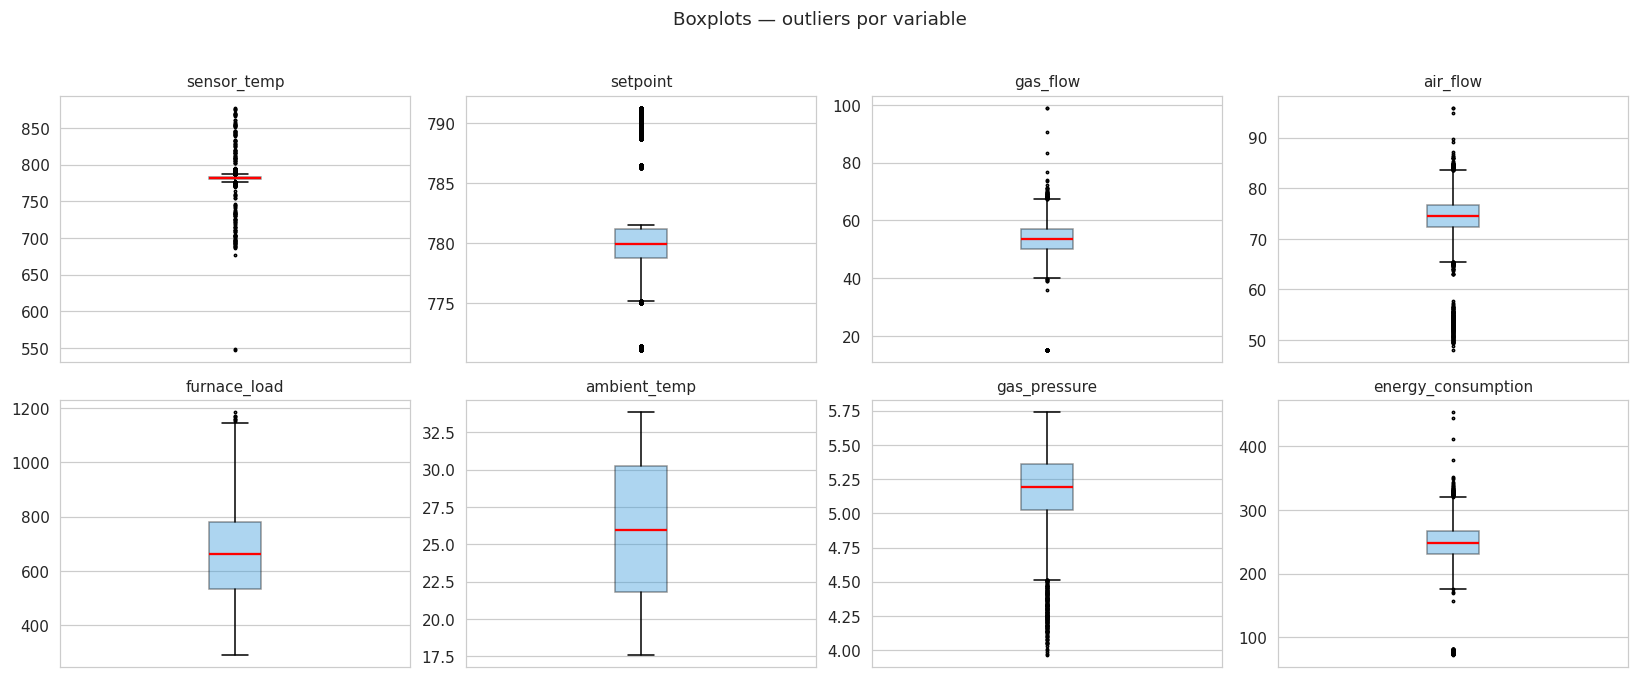

In [ ]:
# Boxplots para visualizar outliers de las 8 variables
variables = ['sensor_temp','setpoint','gas_flow','air_flow',
             'furnace_load','ambient_temp','gas_pressure','energy_consumption']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flat, variables):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.4),
               medianprops=dict(color='red', lw=1.5),
               flierprops=dict(marker='.', markersize=3))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
plt.suptitle('Boxplots — outliers por variable', y=1.02)
plt.tight_layout()
plt.show()


**Lectura:** tras la limpieza, `sensor_temp` muestra una distribución estrecha con algunos outliers que corresponden a transitorios reales (cargas o cambios de setpoint). Las demás variables tienen distribuciones razonables sin valores extremos preocupantes.


## 4. Distribución de variables

Vemos la forma de cada variable con histogramas y una tabla resumen (media, mínimo, máximo, etc.).

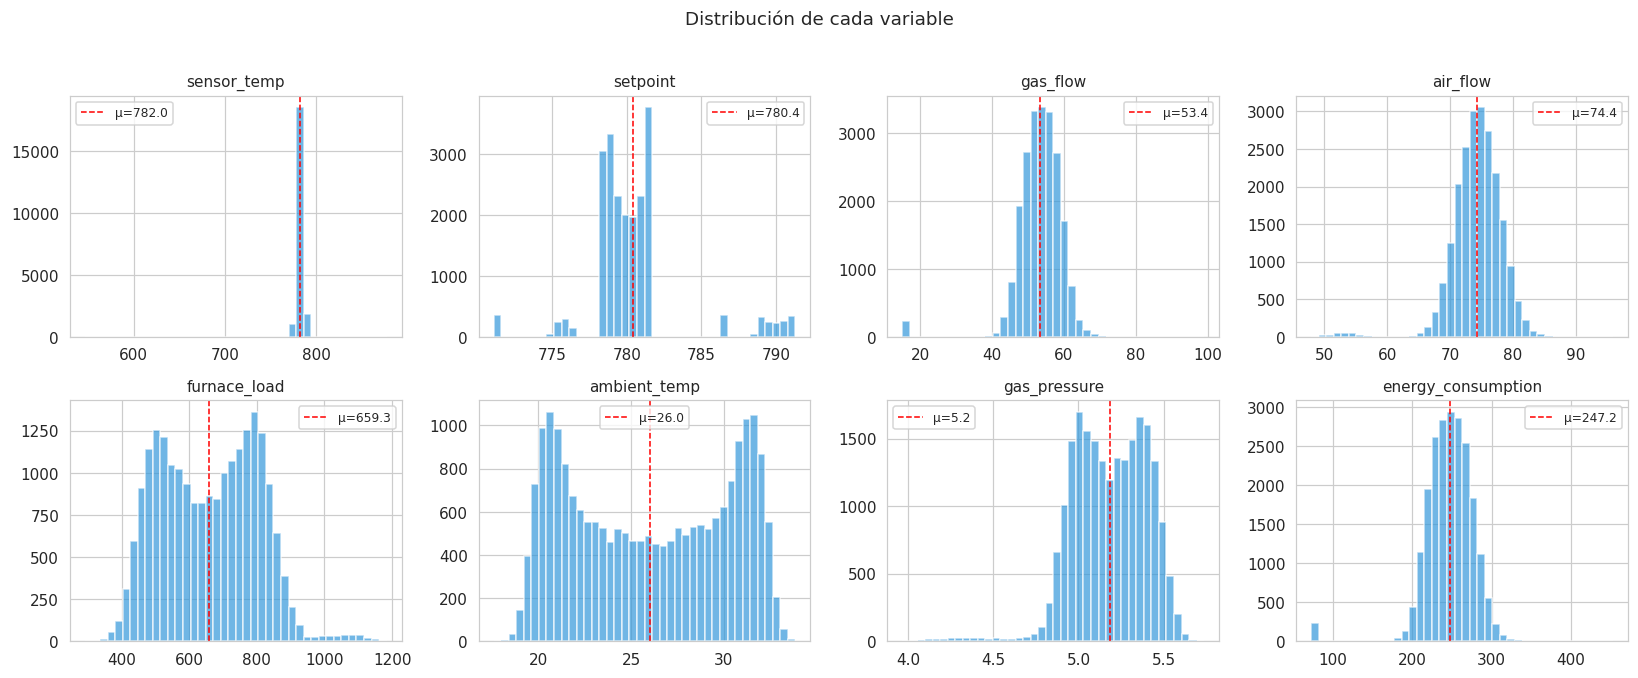

In [ ]:
# Histograma de cada variable con su media (línea roja)
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flat, variables):
  serie = df[col].dropna()
  ax.hist(serie, bins=40, color='#3498db', alpha=0.7, edgecolor='white')
  ax.axvline(serie.mean(), color='red', ls='--', lw=1, label=f'μ={serie.mean():.1f}')
  ax.set_title(col, fontsize=10)
  ax.legend(fontsize=8)
plt.suptitle('Distribución de cada variable', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen
df[variables].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
sensor_temp,21600.0,781.98,6.70,546.50,780.38,781.61,782.89,877.45
setpoint,21600.0,780.42,3.18,771.06,778.80,779.91,781.21,791.30
gas_flow,21600.0,53.41,6.17,15.00,50.27,53.73,57.13,99.04
air_flow,21600.0,74.37,3.93,47.92,72.27,74.52,76.79,95.93
furnace_load,21600.0,659.35,142.98,291.47,532.78,662.51,778.49,1183.94
ambient_temp,21600.0,26.00,4.28,17.61,21.80,25.99,30.22,33.85
gas_pressure,21600.0,5.19,0.22,3.96,5.02,5.19,5.36,5.74
energy_consumption,21600.0,247.23,30.24,72.42,230.18,248.17,266.30,453.06


**Lecturas principales:**

- `sensor_temp` está muy concentrada alrededor de 781 °C, consistente con un proceso bien controlado.
- `setpoint` **no es constante**: varía entre 771 y 791 °C. Esto es importante porque difiere del supuesto del Avance 1 (setpoint fijo en 760 °C) — el horno real opera con referencia dinámica.
- `gas_flow` y `air_flow` se mueven en rangos amplios (gas: 15–99 %, aire: 48–96 %), indicando actividad real del controlador.
- `furnace_load` varía de 291 a 1184 kg, consistente con ciclos de carga/extracción del proceso LPDC.
- Ninguna distribución es claramente gaussiana — es lo esperado en variables de proceso bajo control.


## 5. Correlaciones entre variables

Medimos qué tan relacionadas están las variables entre sí, en el mismo instante, con una matriz de correlación de Pearson.

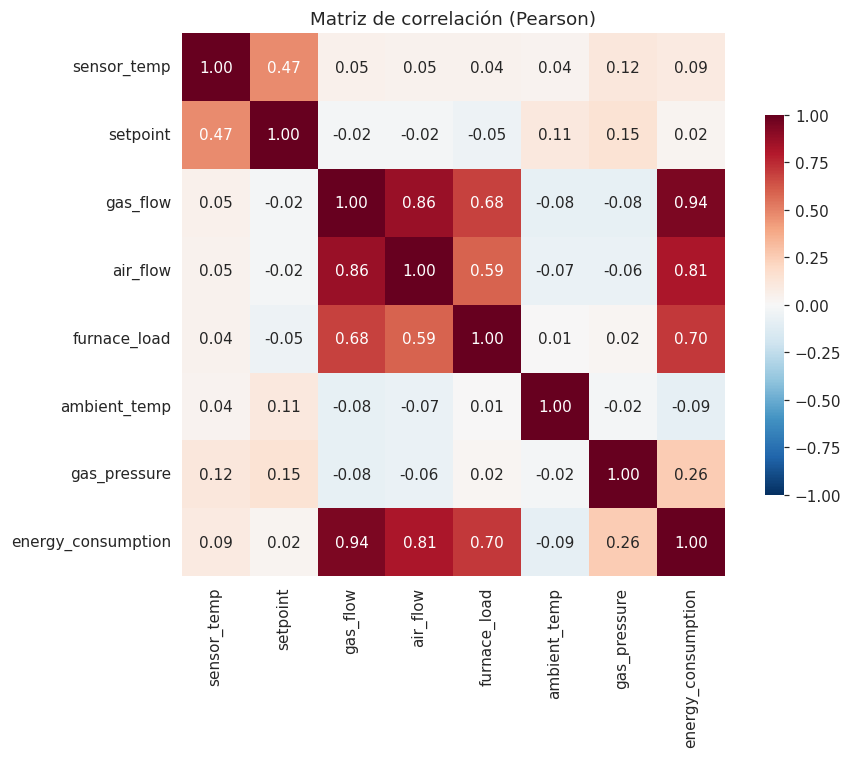

In [ ]:
# Matriz de correlación de Pearson (relación en el mismo instante)
corr = df[variables].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink':0.7})
plt.title('Matriz de correlación (Pearson)')
plt.tight_layout()
plt.show()

**Lecturas:**

- `gas_flow` ↔ `energy_consumption`: correlación fuerte y positiva (el gas es la fuente de energía).
- `gas_flow` ↔ `air_flow`: correlación alta (control estequiométrico de combustión).
- `gas_flow` ↔ `sensor_temp` **es débil instantáneamente**, pero esto **no significa que no haya relación**. La relación está desfasada en el tiempo — el gas calienta primero el refractario, luego el baño. Esto lo confirmamos con la cross-correlación en la sección 7.
- `furnace_load` ↔ `sensor_temp`: correlación negativa moderada — más masa en el baño dificulta mantener temperatura.
- `ambient_temp` tiene correlación muy baja con `sensor_temp` → buen aislamiento del horno.


## 6. Autocorrelación de la temperatura

Medimos qué tanto se parece la temperatura a sí misma cuando la comparamos con sus valores pasados (su "memoria" en el tiempo).

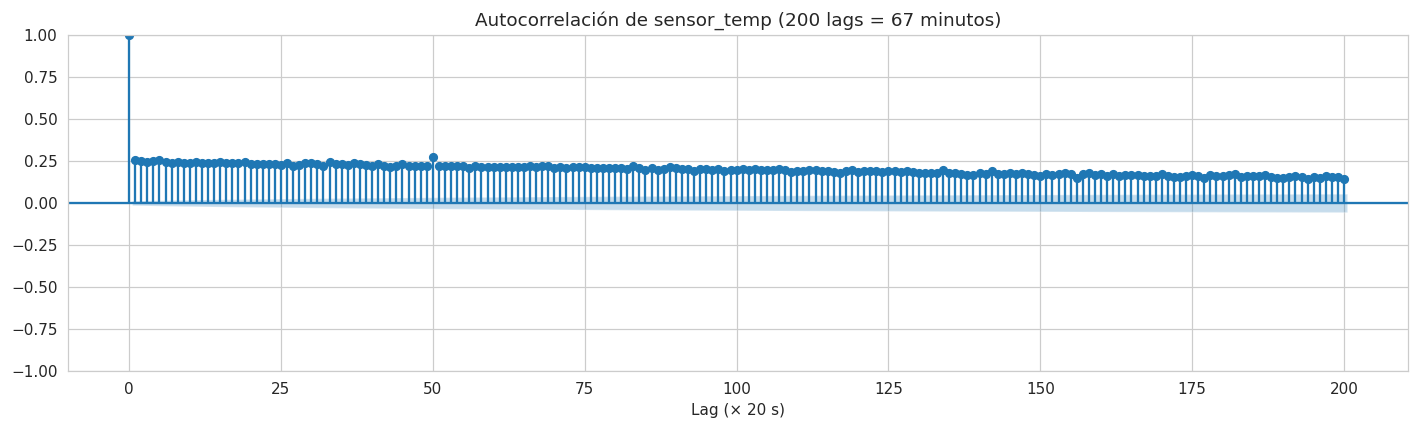

In [ ]:
# Autocorrelación (ACF) de la temperatura hasta 200 lags (~67 min)
fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(df['sensor_temp'].dropna(), lags=200, ax=ax)
ax.set_title('Autocorrelación de sensor_temp (200 lags = 67 minutos)')
ax.set_xlabel('Lag (× 20 s)')
plt.tight_layout()
plt.show()

**Lectura:** la autocorrelación baja despacio, no de golpe. Esto quiere decir que la temperatura de ahora depende mucho de la de hace varios minutos: el horno tiene "memoria" por su inercia térmica. Por eso, para predecirla conviene un modelo que mire varias muestras hacia atrás (ventanas temporales largas), no solo el último valor.

## 7. Análisis espectral

Pasamos la temperatura del "tiempo" a la "frecuencia" para ver si hay ciclos o periodos que se repitan. Usamos el método de Welch (PSD) y la FFT.

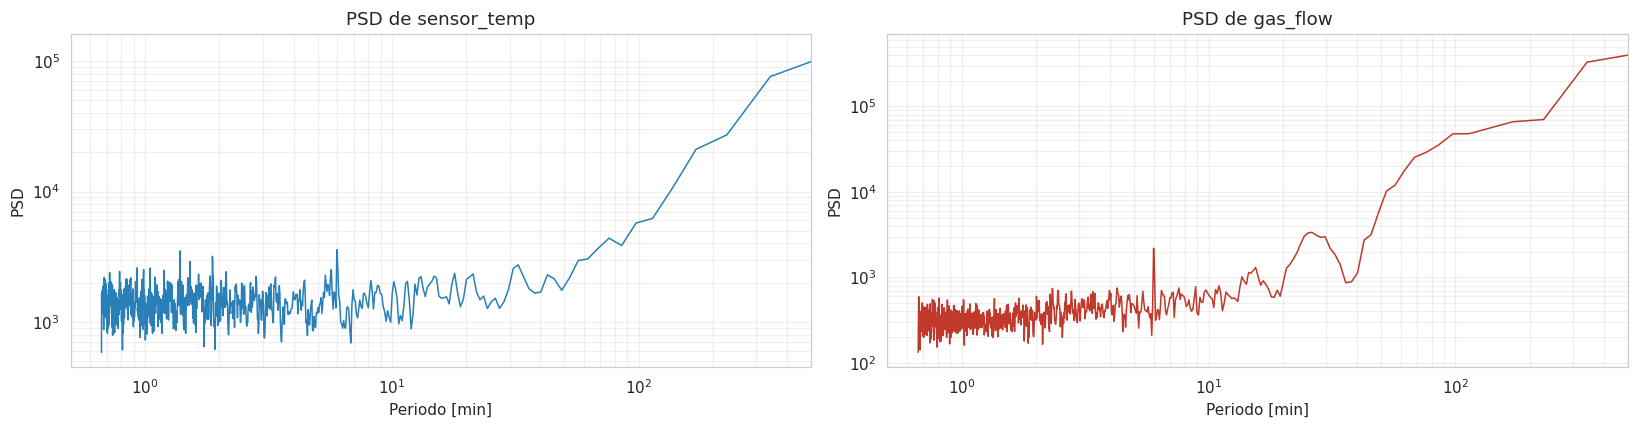

In [ ]:
# Densidad espectral de potencia (Welch) de temperatura y gas; eje x en periodo (min)
fs = 1/20

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, col, color in [(axes[0], 'sensor_temp', '#2980b9'),
                        (axes[1], 'gas_flow', '#c0392b')]:
  serie = df[col].dropna().values
  f, psd = signal.welch(serie - serie.mean(), fs=fs, nperseg=2048)
  periodos_min = 1/(f[1:] * 60)
  ax.semilogy(periodos_min, psd[1:], color=color, lw=1)
  ax.set_xlabel('Periodo [min]')
  ax.set_ylabel('PSD')
  ax.set_xscale('log')
  ax.set_xlim(0.5, 500)
  ax.set_title(f'PSD de {col}')
  ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

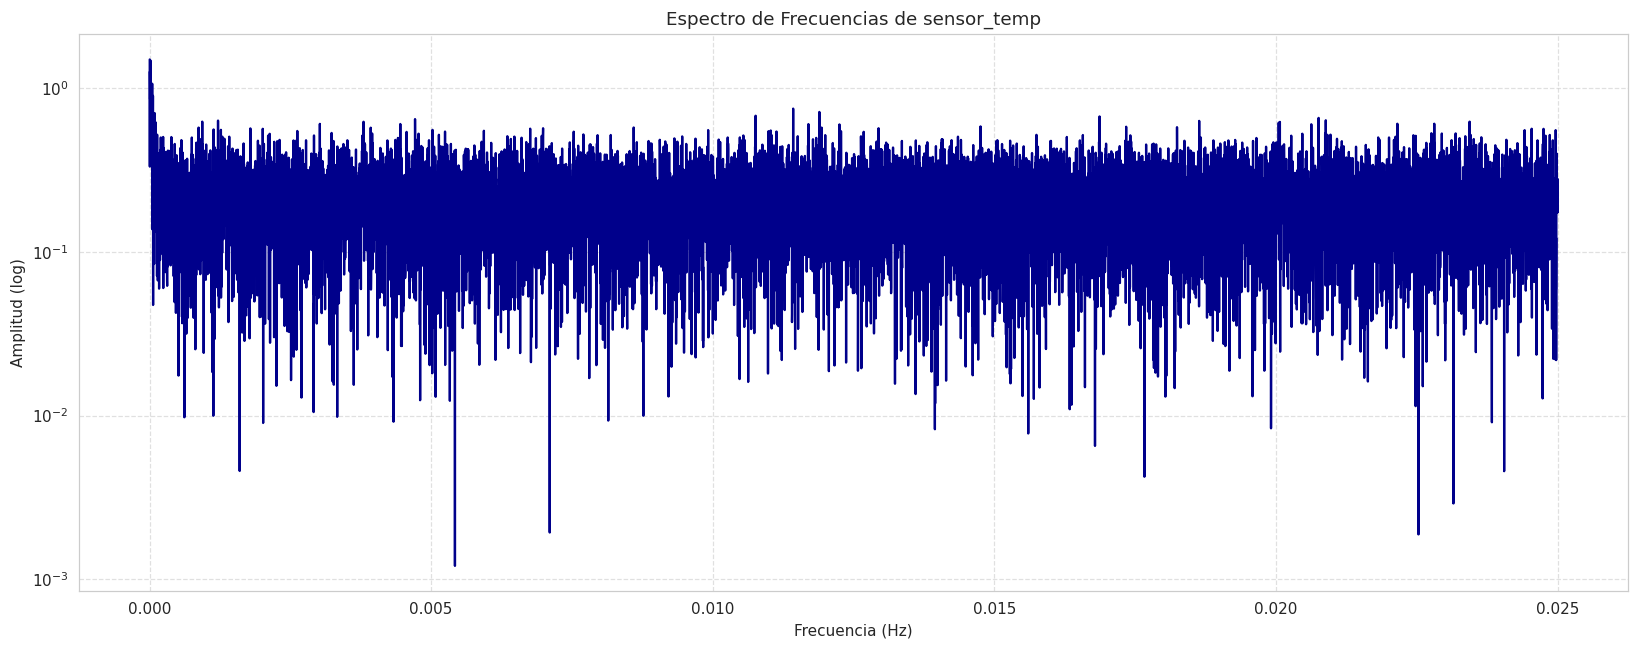

In [16]:
from scipy.fft import fft

# Interpolación lineal para manejar NaNs en sensor_temp para FFT
sensor_temp_interpolated = df['sensor_temp'].interpolate(method='linear').dropna()

# Aplicar FFT
N = len(sensor_temp_interpolated) # Número de puntos en la señal
T = 20 # Intervalo de muestreo en segundos

Y = fft(sensor_temp_interpolated.values)
x_fft = np.linspace(0.0, 1.0/(2.0*T), N//2) # Frecuencias en Hz

# Tomar la magnitud de las primeras N//2 frecuencias (parte positiva del espectro)
amplitudes = 2.0/N * np.abs(Y[0:N//2])

# Crear un DataFrame para analizar frecuencias y periodos
spectrum_df = pd.DataFrame({
    'Frequency_Hz': x_fft,
    'Amplitude': amplitudes
})

# Filtrar frecuencias muy bajas que corresponden a la media o tendencia
spectrum_df = spectrum_df[spectrum_df['Frequency_Hz'] > 0]

plt.figure(figsize=(15, 6))
plt.plot(spectrum_df['Frequency_Hz'], spectrum_df['Amplitude'], color='darkblue')
plt.yscale('log') # Escala logarítmica para ver mejor las amplitudes pequeñas
plt.title('Espectro de Frecuencias de sensor_temp')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (log)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

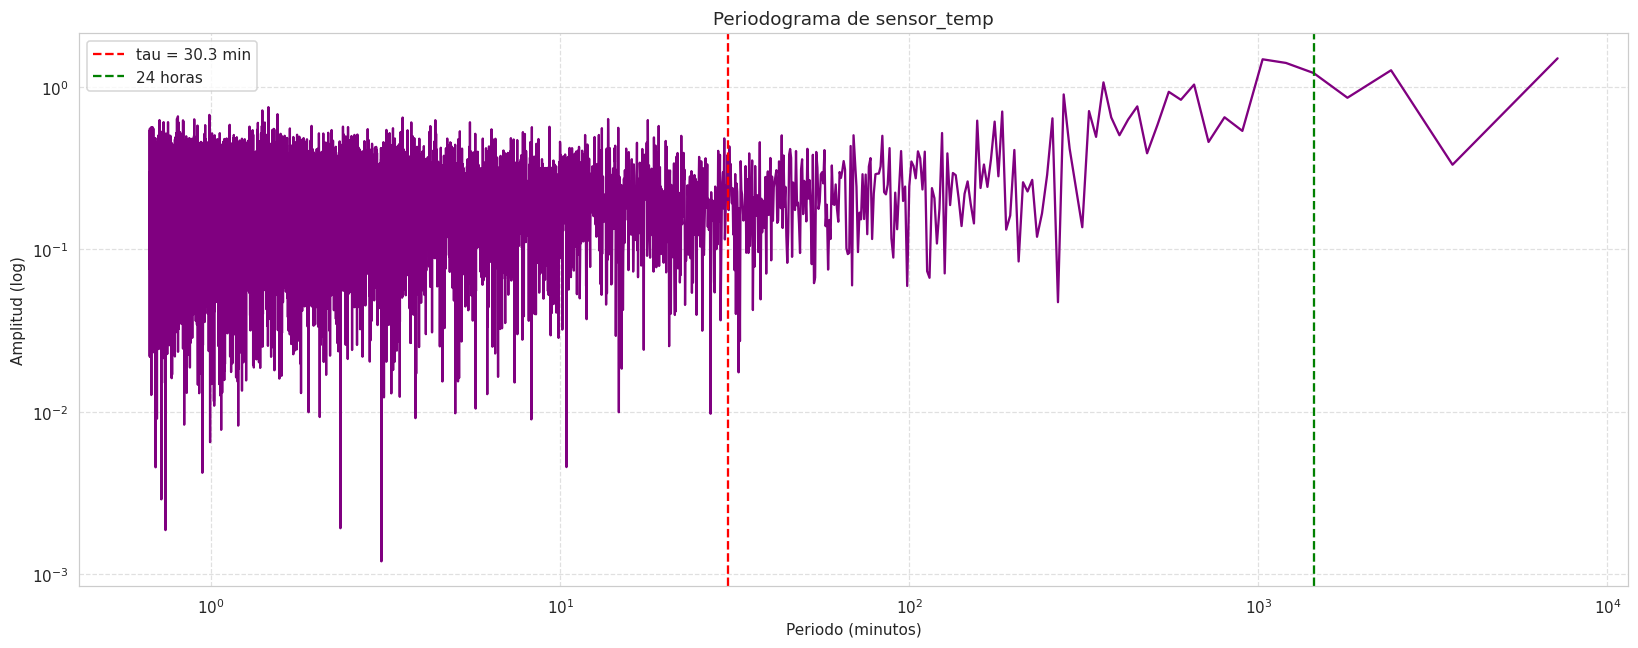

In [18]:
# 2. Periodograma con líneas verticales marcando τ=30.3 min y 24 horas

# Convertir el espectro a periodos para el eje x
spectrum_df_period = spectrum_df.copy()
spectrum_df_period['Period_min'] = 1 / spectrum_df_period['Frequency_Hz'] / 60

plt.figure(figsize=(15, 6))
plt.plot(spectrum_df_period['Period_min'], spectrum_df_period['Amplitude'], color='purple')

# Marcar periodos de interés
plt.axvline(x=30.3, color='red', linestyle='--', label='tau = 30.3 min')
plt.axvline(x=24*60, color='green', linestyle='--', label='24 horas')

plt.xscale('log') # Escala logarítmica para el eje de periodos si hay un rango muy amplio
plt.yscale('log')
plt.title('Periodograma de sensor_temp')
plt.xlabel('Periodo (minutos)')
plt.ylabel('Amplitud (log)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Lectura:** casi toda la energía de la señal está en los periodos largos (frecuencias bajas), no en los cortos. Esto confirma que la temperatura cambia despacio, dominada por la dinámica lenta del horno; la línea de τ ≈ 30.3 min marca ese tiempo característico. No aparece un pico fuerte y angosto, así que no hay un ciclo fijo que domine la señal, algo coherente con un proceso térmico bajo control.

## 8. Relación multivariable

Estudiamos cómo se relaciona la temperatura con otras variables tomando en cuenta el retardo en el tiempo. Usamos cross-correlación (con desfases), un scatter del error de temperatura vs gas y un pairplot.

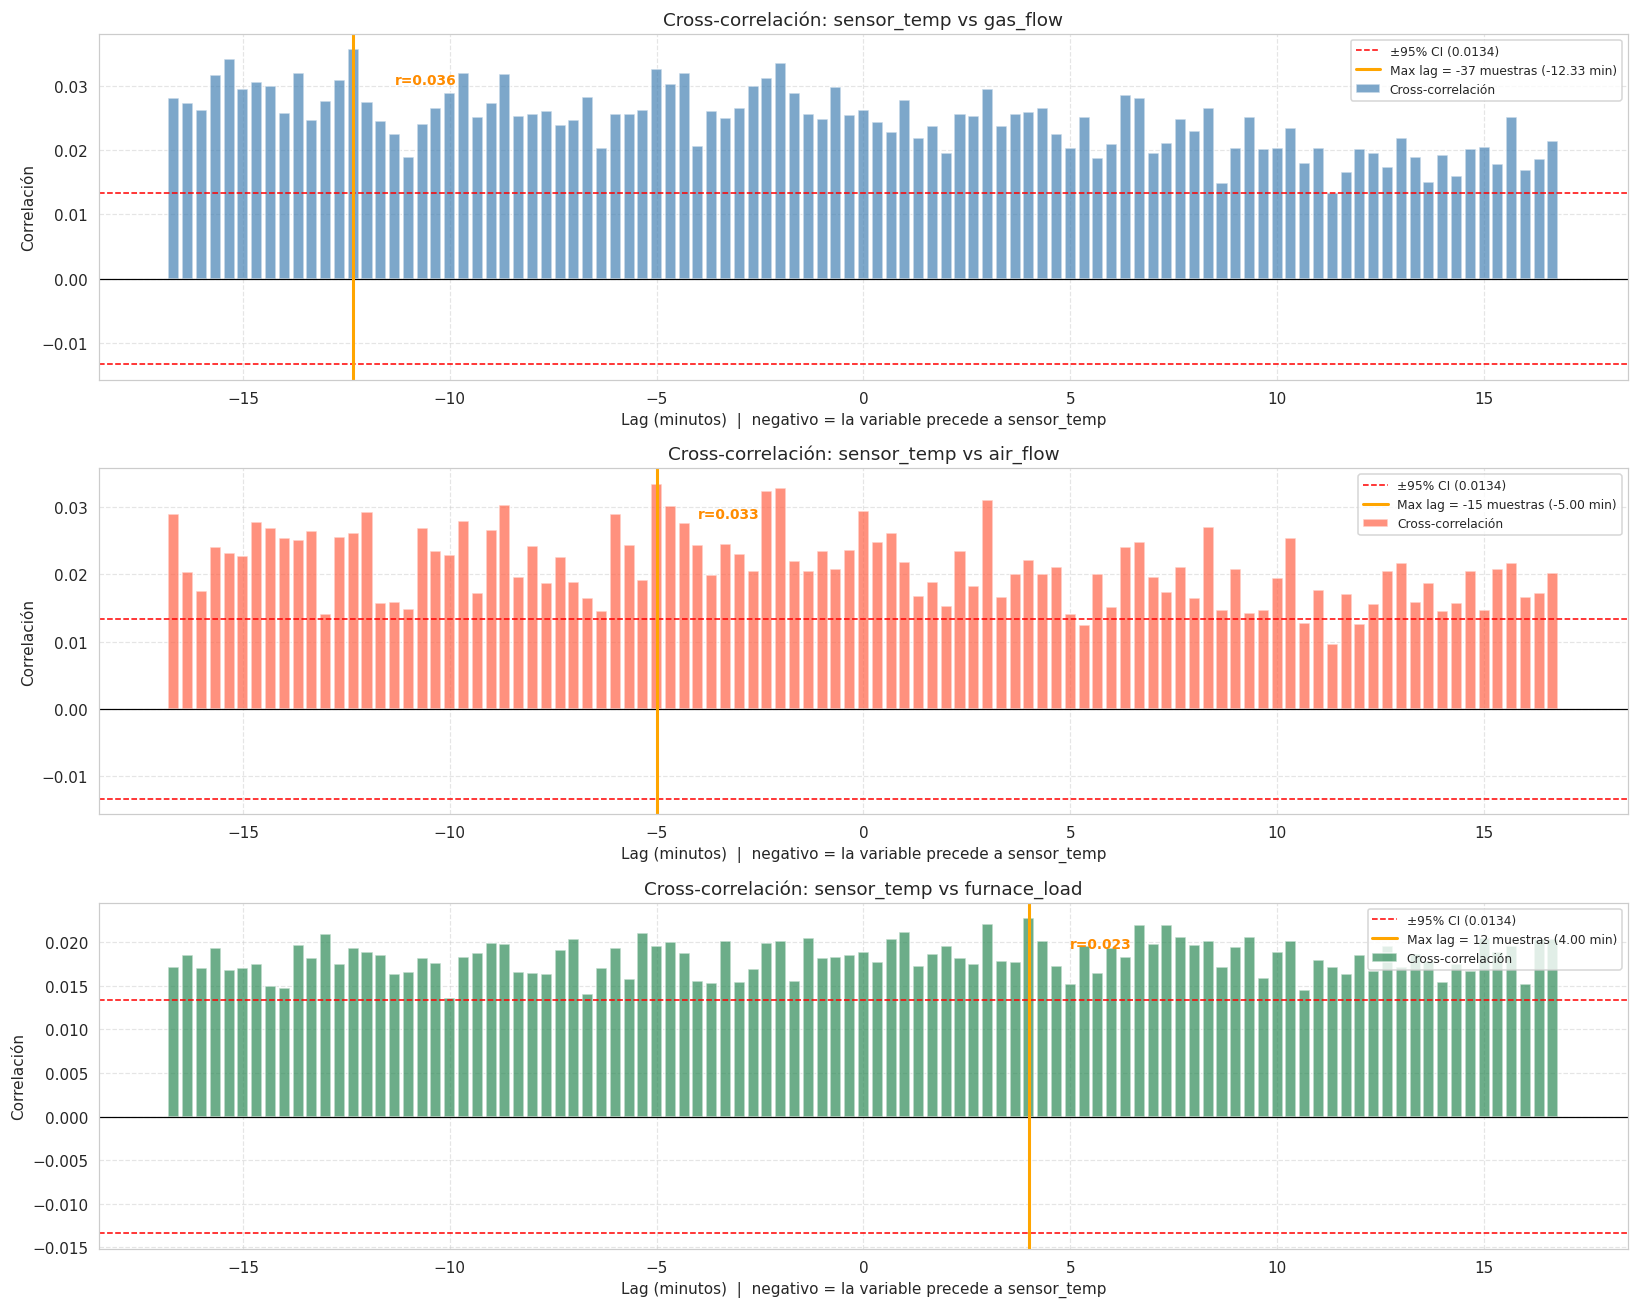

In [13]:
def calculate_ccf_manual(series1, series2, max_lag=50):
  """Cross-correlación entre dos series para desfases de -max_lag a +max_lag.
  Permite ver si una variable se relaciona con otra adelantada o atrasada en el tiempo."""
  combined = pd.DataFrame({'s1': series1, 's2': series2}).dropna()
  s1 = combined['s1'].values
  s2 = combined['s2'].values

  s1_norm = (s1 - s1.mean()) / s1.std()
  s2_norm = (s2 - s2.mean()) / s2.std()

  lags = range(-max_lag, max_lag + 1)
  correlations = []

  for lag in lags:
    if lag < 0:
        corr = np.corrcoef(s1_norm[-lag:], s2_norm[:lag])[0, 1]
    elif lag > 0:
        corr = np.corrcoef(s1_norm[:-lag], s2_norm[lag:])[0, 1]
    else:
        corr = np.corrcoef(s1_norm, s2_norm)[0, 1]
    correlations.append(corr)

  return pd.DataFrame({'Lag': list(lags), 'Correlation': correlations})

df_aligned = df[['sensor_temp', 'gas_flow', 'air_flow', 'furnace_load']].dropna()

ccf_gf_df = calculate_ccf_manual(df_aligned['sensor_temp'], df_aligned['gas_flow'], max_lag=50)
ccf_af_df = calculate_ccf_manual(df_aligned['sensor_temp'], df_aligned['air_flow'], max_lag=50)
ccf_fl_df = calculate_ccf_manual(df_aligned['sensor_temp'], df_aligned['furnace_load'], max_lag=50)

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

N = len(df_aligned)
conf_level = 1.96 / np.sqrt(N)

for ax, ccf_df, var_name, color in zip(
    axes,
    [ccf_gf_df, ccf_af_df, ccf_fl_df],
    ['gas_flow', 'air_flow', 'furnace_load'],
    ['steelblue', 'tomato', 'seagreen']
):
  lags_min = ccf_df['Lag'] * (20 / 60)

  ax.bar(lags_min, ccf_df['Correlation'], width=20/60 * 0.8,
          color=color, alpha=0.7, label='Cross-correlación')

  ax.axhline(y=conf_level,  color='red', linestyle='--', linewidth=1, label=f'±95% CI ({conf_level:.4f})')
  ax.axhline(y=-conf_level, color='red', linestyle='--', linewidth=1)
  ax.axhline(y=0, color='black', linewidth=0.8)

  idx_max = ccf_df['Correlation'].abs().idxmax()
  lag_max_min = ccf_df.loc[idx_max, 'Lag'] * (20 / 60)
  corr_max = ccf_df.loc[idx_max, 'Correlation']
  ax.axvline(x=lag_max_min, color='orange', linestyle='-', linewidth=2,
              label=f'Max lag = {ccf_df.loc[idx_max, "Lag"]} muestras ({lag_max_min:.2f} min)')
  ax.annotate(f'r={corr_max:.3f}', xy=(lag_max_min, corr_max),
              xytext=(lag_max_min + 1, corr_max * 0.85),
              fontsize=9, color='darkorange', fontweight='bold')

  ax.set_title(f'Cross-correlación: sensor_temp vs {var_name}', fontsize=12)
  ax.set_xlabel('Lag (minutos)  |  negativo = la variable precede a sensor_temp')
  ax.set_ylabel('Correlación')
  ax.legend(fontsize=8, loc='upper right')
  ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

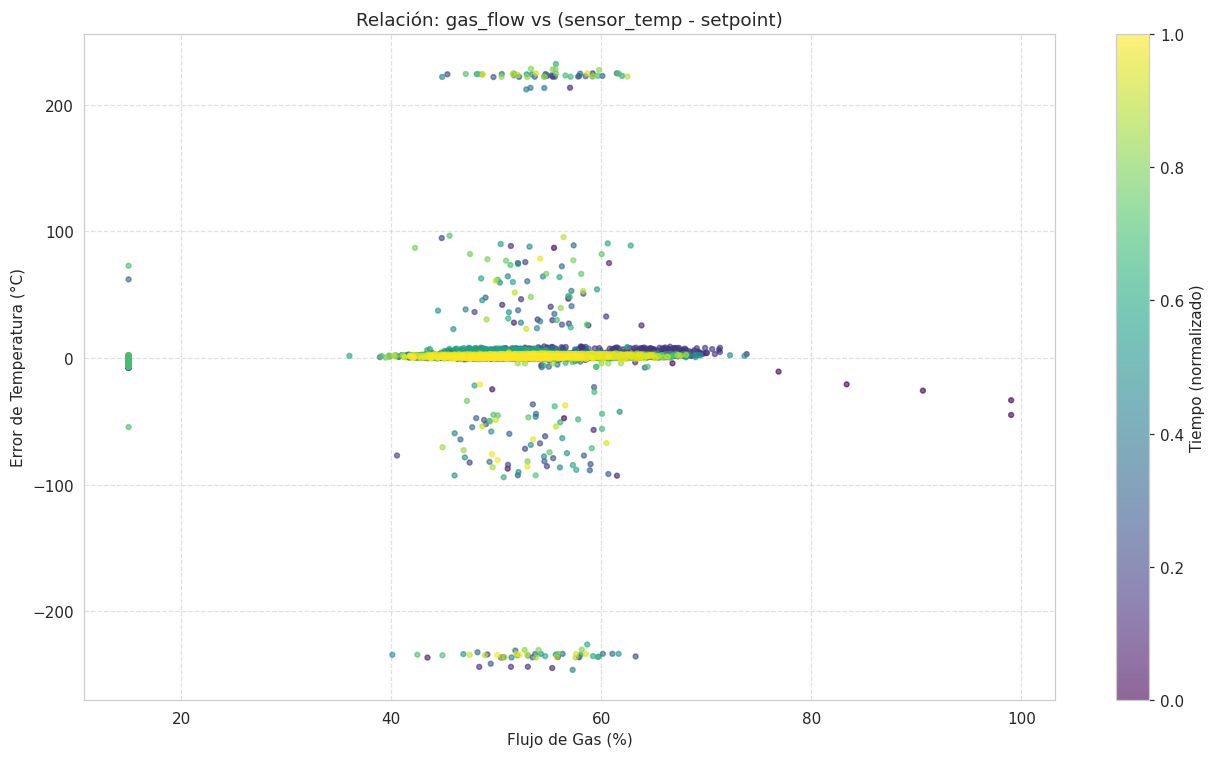

In [11]:
# Scatter: error de temperatura (sensor - setpoint) vs flujo de gas; color = tiempo
df_gas_flow = df.dropna(subset=['gas_flow']).copy()
df_gas_flow['gas_flow_diff'] = df_gas_flow['gas_flow'].diff().abs()

plt.figure(figsize=(12, 7))

time_normalized = (df_gas_flow.index.to_series() - df_gas_flow.index.min()).dt.total_seconds()
time_normalized = (time_normalized - time_normalized.min()) / (time_normalized.max() - time_normalized.min())

scatter = plt.scatter(df_gas_flow['gas_flow'], (df_gas_flow['sensor_temp'] - df_gas_flow['setpoint']),
                        c=time_normalized, cmap='viridis', alpha=0.6, s=10)
cbar = plt.colorbar(scatter)
cbar.set_label('Tiempo (normalizado)')

plt.title('Relación: gas_flow vs (sensor_temp - setpoint)')
plt.xlabel('Flujo de Gas (%)')
plt.ylabel('Error de Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

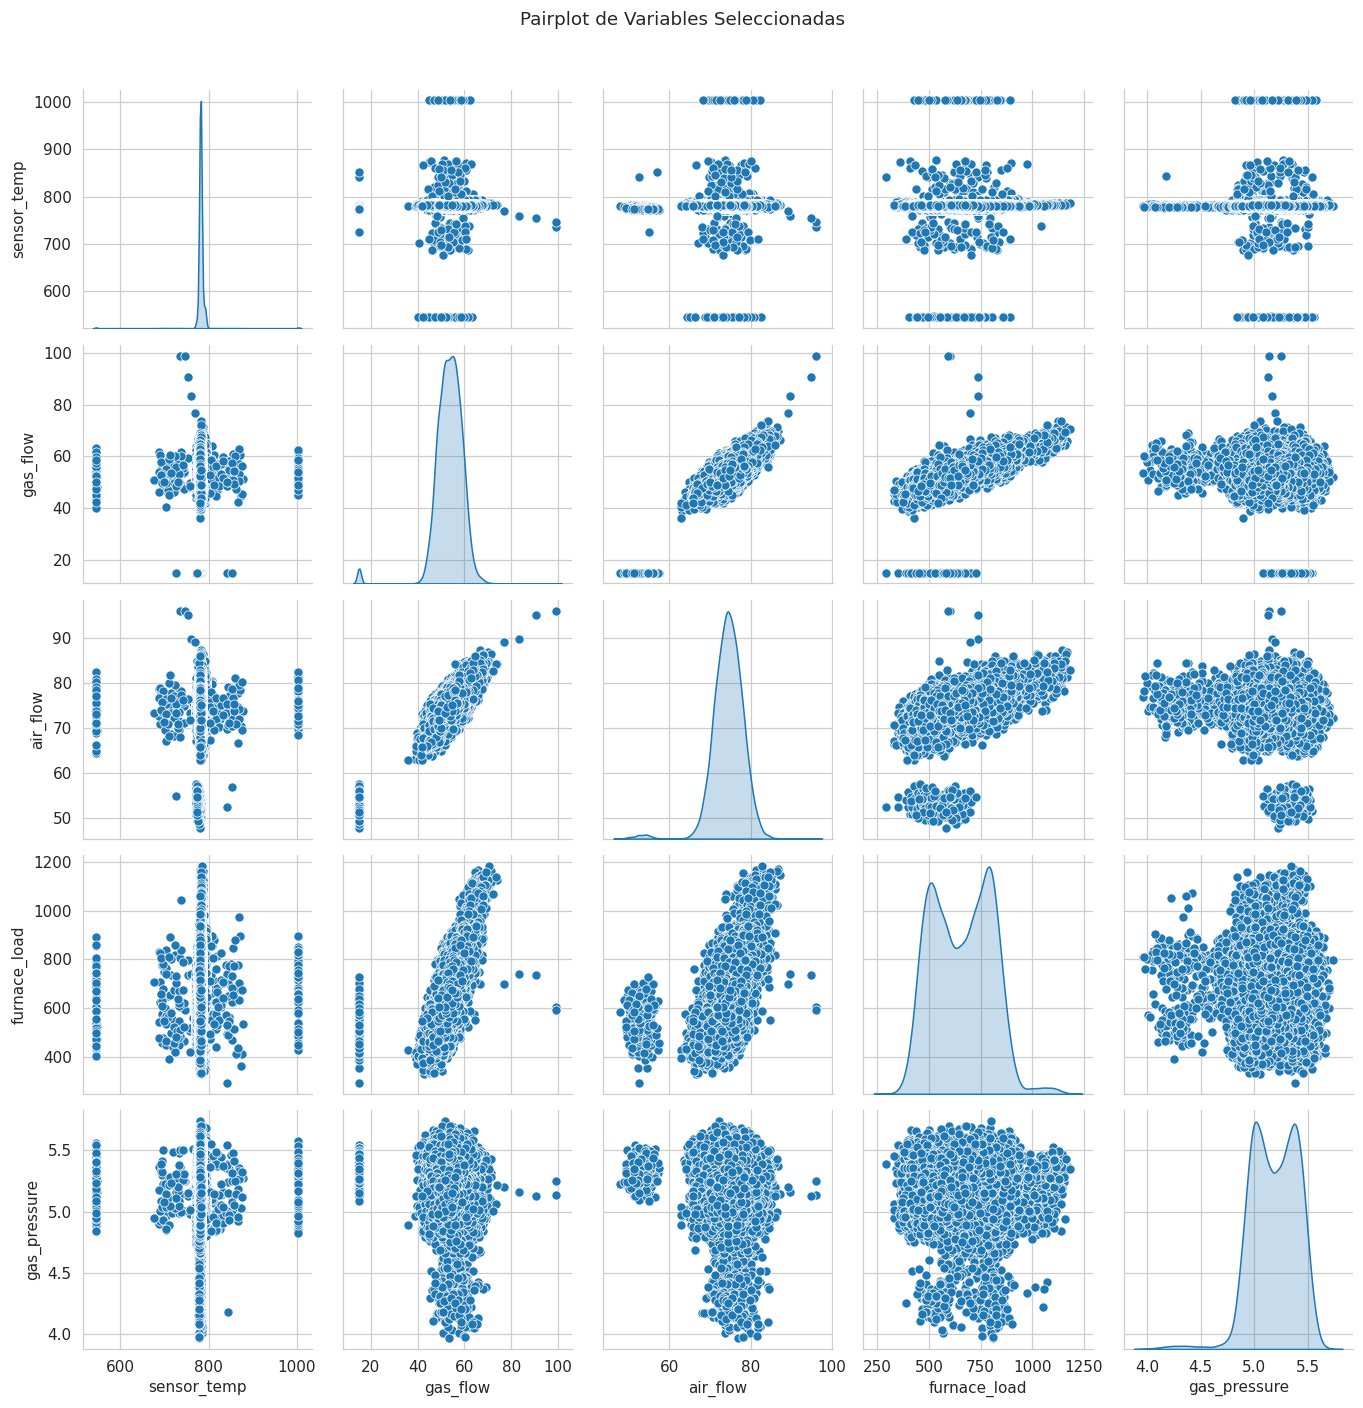

In [12]:
# Pairplot: relaciones por pares de variables seleccionadas
columns_for_pairplot = ['sensor_temp', 'gas_flow', 'air_flow', 'furnace_load', 'gas_pressure']
df_pairplot = df[columns_for_pairplot].dropna()

sns.pairplot(df_pairplot, diag_kind='kde')
plt.suptitle('Pairplot de Variables Seleccionadas', y=1.02)
plt.tight_layout()
plt.show()

**Lectura:** la correlación más fuerte entre `gas_flow` y `sensor_temp` no ocurre en el desfase 0, sino en un desfase distinto de cero. Esto confirma lo de la sección 5: el gas no calienta el baño al instante, primero calienta el refractario y luego sube la temperatura, así que el efecto llega con retardo (tiempo muerto / inercia térmica). `furnace_load` se relaciona de forma negativa, igual que en la matriz de correlación: más masa cuesta más mantener la temperatura. El scatter y el pairplot complementan visualmente estas relaciones.